# §5 Reported Compute Capacity

Growth of reported accelerator capacity in science: FLOPS, VRAM, device
scale-out, precision mix, and concentration — with the vendor frontier
overlaid.

> **All capacity figures measure reported NAMEPLATE PEAK capacity, not utilized
> FLOPs.** They capture the compute a paper had access to and chose to report:
> an upper bound on work performed. Per-device specs come from the scraped
> registry (`registry/generated/wikipedia.yaml`), never from hardcoded values.

**Kernel:** Python (accelscan); launch from a shell with `set -a; source .env; set +a`.

**Inputs:** `accelscan.compute` output (per-paper capacity) + registry specs
(frontier) + `accelscan.precision` flags. Run those stages first:

```bash
python -m accelscan.compute                       # -> s3 .../capacity/...
python -m accelscan.compute --count-policy explicit   # robustness variant
python -m accelscan.precision                     # -> s3 .../precision/...
```

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import polars as pl
from accelscan.compute import AXES, spec_frame
from accelscan.config import BUCKET, OUT_PREFIX, PAPERS_PREFIX
from accelscan.registry import load_registry
from accelscan.s3 import storage_options
from accelscan.plotting import install_year_tick_fix

install_year_tick_fix()   # no fractional year ticks (2007.5) on any figure

## Knobs

In [2]:
COUNT_POLICY = 'floor1'      # 'floor1' (primary) | 'explicit' (robustness)
MODEL_TAG, PROMPT_VERSION = 'qwen3-14b', 'p1'
YEAR_MIN, YEAR_MAX = 2008, 2025
LOCAL_CAPACITY = None        # e.g. 'output/compute_smoke' to read a local smoke run
LOCAL_PRECISION = None       # e.g. 'output/precision_smoke'
MIN_PAPERS_PER_YEAR = 25     # suppress year points with too little support

CAVEAT = 'Reported nameplate peak capacity, not utilized FLOPs'
C_MED, C_P90, C_FRONT = '#0072B2', '#56B4E9', '#D55E00'
reg = load_registry()
so = storage_options()

## Load per-paper capacity + year/field

In [3]:
if LOCAL_CAPACITY:
    cap = pl.read_parquet(f'{LOCAL_CAPACITY}/paper_capacity_{COUNT_POLICY}.parquet')
else:
    key = (f's3://{BUCKET}/{OUT_PREFIX}/capacity/{reg.version}/{PROMPT_VERSION}'
           f'/{MODEL_TAG}/paper_capacity_{COUNT_POLICY}.parquet')
    cap = pl.read_parquet(key, storage_options=so)

fields = (pl.scan_parquet(f's3://{BUCKET}/{PAPERS_PREFIX}*.parquet', storage_options=so)
          .select('corpusid', 's2fieldsofstudy')
          .filter(pl.col('corpusid').is_in(cap['corpusid'].to_list()))
          .with_columns(field=pl.col('s2fieldsofstudy').list.first().struct.field('category'))
          .select('corpusid', 'field').collect())
cap = (cap.join(fields, on='corpusid', how='left')
       .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX)))
print(f'{cap.height:,} papers | policy={COUNT_POLICY} '
      f'| specs from registry v{cap["spec_registry_version"][0]} '
      f'| mentions from v{cap["mentions_registry_version"][0]}')

209,665 papers | policy=floor1 | specs from registry v0.2.0 | mentions from v0.1.0


## Spec coverage by year (publish alongside every capacity figure)

Papers whose used models lack a spec on an axis are excluded from that axis
(never zero-filled). Coverage that drifts across eras would bias trends, so it
is reported explicitly.

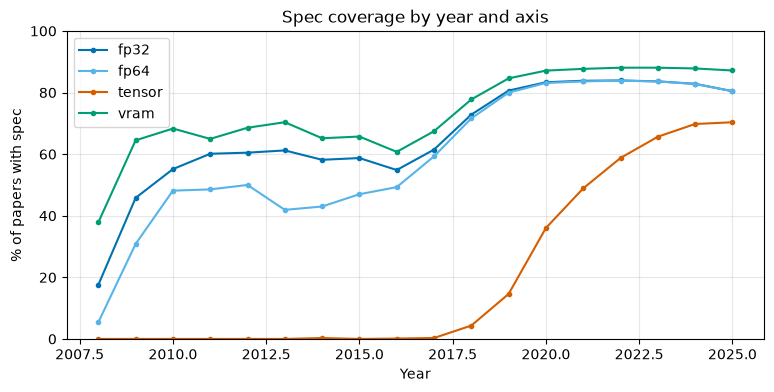

shape: (18, 6)
┌──────┬────────┬──────────┬──────────┬────────────┬──────────┐
│ year ┆ papers ┆ cov_fp32 ┆ cov_fp64 ┆ cov_tensor ┆ cov_vram │
│ ---  ┆ ---    ┆ ---      ┆ ---      ┆ ---        ┆ ---      │
│ i64  ┆ u32    ┆ f64      ┆ f64      ┆ f64        ┆ f64      │
╞══════╪════════╪══════════╪══════════╪════════════╪══════════╡
│ 2008 ┆ 74     ┆ 0.175676 ┆ 0.054054 ┆ 0.0        ┆ 0.378378 │
│ 2009 ┆ 107    ┆ 0.457944 ┆ 0.308411 ┆ 0.0        ┆ 0.64486  │
│ 2010 ┆ 243    ┆ 0.55144  ┆ 0.481481 ┆ 0.0        ┆ 0.683128 │
│ 2011 ┆ 311    ┆ 0.601286 ┆ 0.485531 ┆ 0.0        ┆ 0.649518 │
│ 2012 ┆ 420    ┆ 0.604762 ┆ 0.5      ┆ 0.0        ┆ 0.685714 │
│ 2013 ┆ 513    ┆ 0.612086 ┆ 0.419103 ┆ 0.0        ┆ 0.703704 │
│ 2014 ┆ 686    ┆ 0.581633 ┆ 0.430029 ┆ 0.002915   ┆ 0.651603 │
│ 2015 ┆ 945    ┆ 0.587302 ┆ 0.469841 ┆ 0.0        ┆ 0.657143 │
│ 2016 ┆ 1694   ┆ 0.548406 ┆ 0.492916 ┆ 0.001181   ┆ 0.607438 │
│ 2017 ┆ 3219   ┆ 0.614787 ┆ 0.592731 ┆ 0.003107   ┆ 0.674433 │
│ 2018 ┆ 5922   ┆ 0.72830

In [4]:
cov = (cap.group_by('year').agg(
        papers=pl.len(),
        **{f'cov_{a}': (~pl.col(f'spec_missing_{a}')).mean() for a in AXES},
        cov_vram=(~pl.col('spec_missing_vram')).mean())
       .sort('year'))
fig, ax = plt.subplots(figsize=(9, 4))
for a, c in zip(list(AXES) + ['vram'], [C_MED, C_P90, C_FRONT, '#009E73']):
    ax.plot(cov['year'], 100 * cov[f'cov_{a}'], marker='o', ms=3, label=a, color=c)
ax.set(xlabel='Year', ylabel='% of papers with spec', ylim=(0, 100),
       title='Spec coverage by year and axis')
ax.legend(); ax.grid(alpha=0.3); plt.show()
with pl.Config(tbl_rows=20):
    print(cov)

## 5.1 Reported FLOPS growth vs the vendor frontier

The frontier line is the maximum single-device FP32 spec among **data-center**
GPUs released up to that year (from the registry) — i.e. the best chip money
could buy. The gap between the paper distribution and that line is the
science-vs-frontier divergence.

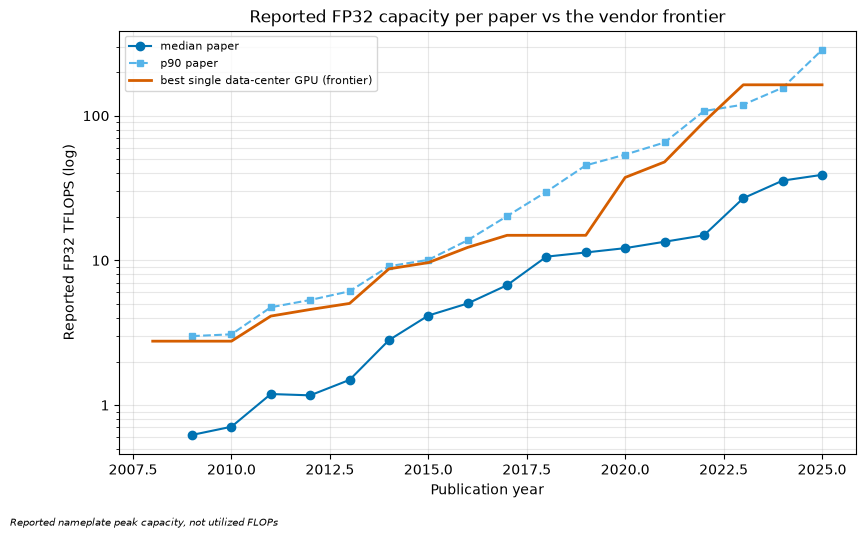

shape: (17, 5)
┌──────┬───────┬────────────┬────────────┬──────────────┐
│ year ┆ n     ┆ med_tflops ┆ p90_tflops ┆ total_pflops │
│ ---  ┆ ---   ┆ ---        ┆ ---        ┆ ---          │
│ i64  ┆ u32   ┆ f64        ┆ f64        ┆ f64          │
╞══════╪═══════╪════════════╪════════════╪══════════════╡
│ 2009 ┆ 49    ┆ 0.62       ┆ 3.0        ┆ 0.2          │
│ 2010 ┆ 134   ┆ 0.71       ┆ 3.1        ┆ 0.5          │
│ 2011 ┆ 187   ┆ 1.19       ┆ 4.7        ┆ 11.4         │
│ 2012 ┆ 254   ┆ 1.17       ┆ 5.3        ┆ 6.6          │
│ 2013 ┆ 314   ┆ 1.49       ┆ 6.1        ┆ 36.8         │
│ 2014 ┆ 399   ┆ 2.81       ┆ 9.1        ┆ 240.7        │
│ 2015 ┆ 555   ┆ 4.16       ┆ 10.1       ┆ 10.4         │
│ 2016 ┆ 929   ┆ 5.04       ┆ 13.8       ┆ 199.7        │
│ 2017 ┆ 1979  ┆ 6.74       ┆ 20.2       ┆ 100.5        │
│ 2018 ┆ 4313  ┆ 10.61      ┆ 29.8       ┆ 512.9        │
│ 2019 ┆ 4917  ┆ 11.34      ┆ 45.4       ┆ 267.9        │
│ 2020 ┆ 12700 ┆ 12.15      ┆ 53.8       ┆ 1545.1       │

In [5]:
specs = spec_frame(reg)

def frontier(axis_col: str, segment: str = 'datacenter') -> pl.DataFrame:
    """Best single-device spec available up to each year (the vendor frontier)."""
    s = (specs.filter(pl.col('segment') == segment)
         .filter(pl.col(axis_col).is_not_null() & pl.col('release_year').is_not_null()))
    rows = []
    for y in range(YEAR_MIN, YEAR_MAX + 1):
        avail = s.filter(pl.col('release_year') <= y)
        if avail.height:
            rows.append({'year': y, 'frontier': avail[axis_col].max()})
    return pl.DataFrame(rows)

def capacity_by_year(col: str, missing_flag: str) -> pl.DataFrame:
    d = cap.filter(~pl.col(missing_flag) & pl.col(col).is_not_null())
    return (d.group_by('year').agg(n=pl.len(),
                                   med=pl.col(col).median(),
                                   p90=pl.col(col).quantile(0.9),
                                   total=pl.col(col).sum())
            .filter(pl.col('n') >= MIN_PAPERS_PER_YEAR).sort('year'))

fl = capacity_by_year('reported_fp32_gflops', 'spec_missing_fp32')
fr = frontier('fp32_gflops')
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(fl['year'], fl['med'] / 1000, marker='o', color=C_MED, label='median paper')
ax.plot(fl['year'], fl['p90'] / 1000, marker='s', ms=4, ls='--', color=C_P90, label='p90 paper')
ax.plot(fr['year'], fr['frontier'] / 1000, color=C_FRONT, lw=2,
        label='best single data-center GPU (frontier)')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
ax.set(xlabel='Publication year', ylabel='Reported FP32 TFLOPS (log)',
       title='Reported FP32 capacity per paper vs the vendor frontier')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
fig.text(0.01, -0.02, CAVEAT, fontsize=7, style='italic')
plt.show()
with pl.Config(tbl_rows=20):
    print(fl.with_columns(med_tflops=(pl.col('med')/1000).round(2),
                          p90_tflops=(pl.col('p90')/1000).round(1),
                          total_pflops=(pl.col('total')/1e6).round(1))
          .select('year','n','med_tflops','p90_tflops','total_pflops'))

## 5.2 Reported VRAM growth

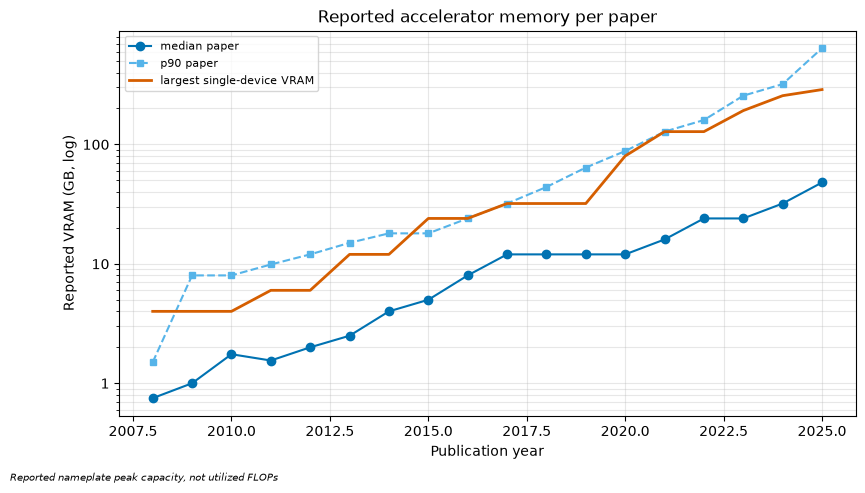

In [6]:
vm = capacity_by_year('reported_vram_gb', 'spec_missing_vram')
frv = frontier('vram_gb')
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(vm['year'], vm['med'], marker='o', color=C_MED, label='median paper')
ax.plot(vm['year'], vm['p90'], marker='s', ms=4, ls='--', color=C_P90, label='p90 paper')
ax.plot(frv['year'], frv['frontier'], color=C_FRONT, lw=2, label='largest single-device VRAM')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
ax.set(xlabel='Publication year', ylabel='Reported VRAM (GB, log)',
       title='Reported accelerator memory per paper')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
fig.text(0.01, -0.02, CAVEAT, fontsize=7, style='italic'); plt.show()

## 5.3 Device scale-out

Is science still single-GPU? `max_devices` is the largest per-model device count
a paper reports (winsorized). Shares are of spec-independent papers, so this
figure does not depend on spec coverage.

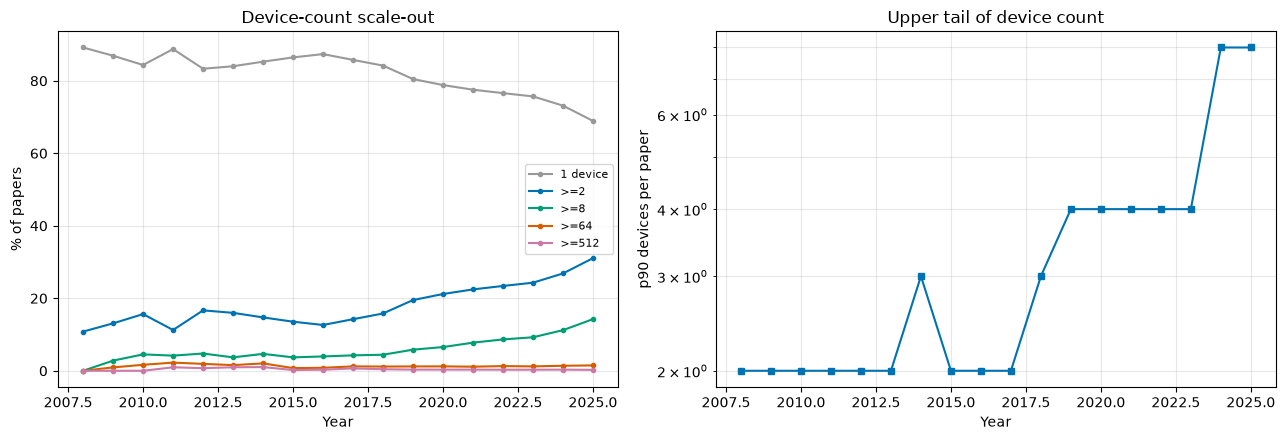

In [7]:
sc = (cap.filter(pl.col('max_devices').is_not_null())
      .group_by('year').agg(
          n=pl.len(),
          single=(pl.col('max_devices') <= 1).mean(),
          ge2=(pl.col('max_devices') >= 2).mean(),
          ge8=(pl.col('max_devices') >= 8).mean(),
          ge64=(pl.col('max_devices') >= 64).mean(),
          ge512=(pl.col('max_devices') >= 512).mean(),
          p90=pl.col('max_devices').quantile(0.9))
      .filter(pl.col('n') >= MIN_PAPERS_PER_YEAR).sort('year'))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for lbl, col, c in [('1 device', 'single', '#999999'), ('>=2', 'ge2', C_MED),
                    ('>=8', 'ge8', '#009E73'), ('>=64', 'ge64', C_FRONT),
                    ('>=512', 'ge512', '#CC79A7')]:
    axes[0].plot(sc['year'], 100 * sc[col], marker='o', ms=3, label=lbl, color=c)
axes[0].set(xlabel='Year', ylabel='% of papers', title='Device-count scale-out')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].plot(sc['year'], sc['p90'], marker='s', ms=4, color=C_MED)
axes[1].set(xlabel='Year', ylabel='p90 devices per paper', title='Upper tail of device count')
axes[1].set_yscale('log'); axes[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## 5.4 Precision: capability vs choice

`tensor_capable` is a **capability** measure (does the used hardware have tensor
units — from registry specs). The `prec_*` flags are **choices** the authors
report in the hardware passage. The gap between them is the finding: capability
turns over with hardware purchases, whereas reported precision practice can move
faster (or lag).

*Precision flags are a lower bound — the sweep sees only candidate passages.*

precision table unavailable — run `python -m accelscan.precision`: object-store error: Object at location accelscan/precision/0.1.0/paper_precision.parquet not found: Error performing HEAD https://s3.msi.umn.edu/scirec-embeddings/accelscan/precision/0.1.0/paper_precision.parquet in 7.1875ms - Server returned non-2xx status code: 404 Not Found:  (path: s3://scirec-embeddings/accelscan/capacity/0.2.0/p1/qwen3-14b/paper_capacity_floor1.parquet)


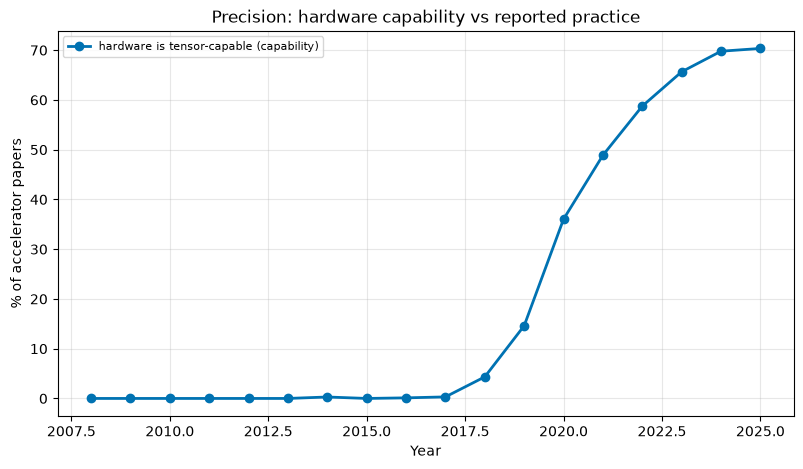

In [8]:
tc = (cap.group_by('year').agg(n=pl.len(), tensor_capable=pl.col('tensor_capable').mean())
      .filter(pl.col('n') >= MIN_PAPERS_PER_YEAR).sort('year'))
prec = None
try:
    if LOCAL_PRECISION:
        prec = pl.read_parquet(f'{LOCAL_PRECISION}/paper_precision.parquet')
    else:
        prec = pl.read_parquet(
            f's3://{BUCKET}/{OUT_PREFIX}/precision/0.1.0/paper_precision.parquet',
            storage_options=so)
except Exception as e:
    print('precision table unavailable — run `python -m accelscan.precision`:', e)

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(tc['year'], 100 * tc['tensor_capable'], marker='o', color=C_MED, lw=2,
        label='hardware is tensor-capable (capability)')
if prec is not None:
    pj = cap.select('corpusid', 'year').join(prec, on='corpusid', how='inner')
    pg = (pj.group_by('year').agg(n=pl.len(),
                                  **{k: pl.col(f'prec_{k}').mean() for k in
                                     ['fp16', 'bf16', 'mixed_precision', 'quantization', 'fp64']})
          .filter(pl.col('n') >= MIN_PAPERS_PER_YEAR).sort('year'))
    for k, c in [('mixed_precision', C_FRONT), ('fp16', '#009E73'),
                 ('bf16', '#CC79A7'), ('quantization', '#E69F00'), ('fp64', '#999999')]:
        ax.plot(pg['year'], 100 * pg[k], marker='.', ls='--', label=f'reports {k}', color=c)
ax.set(xlabel='Year', ylabel='% of accelerator papers',
       title='Precision: hardware capability vs reported practice')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()

## 5.5 Concentration of reported compute

Within-year Gini and top-1% share of reported FP32 capacity: is scientific
compute becoming concentrated in a few papers? (Policy relevance: access
programs such as NAIRR.)

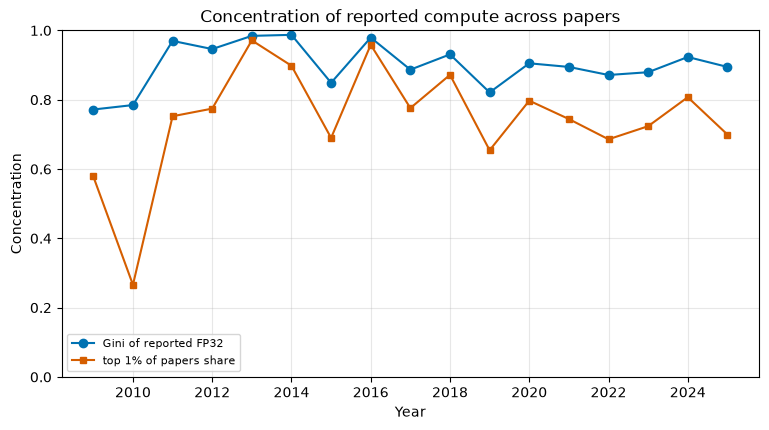

shape: (17, 4)
┌──────┬───────┬───────┬───────────────┐
│ year ┆ n     ┆ gini  ┆ top1pct_share │
│ ---  ┆ ---   ┆ ---   ┆ ---           │
│ i64  ┆ i64   ┆ f64   ┆ f64           │
╞══════╪═══════╪═══════╪═══════════════╡
│ 2009 ┆ 49    ┆ 0.772 ┆ 0.579         │
│ 2010 ┆ 134   ┆ 0.785 ┆ 0.266         │
│ 2011 ┆ 187   ┆ 0.97  ┆ 0.752         │
│ 2012 ┆ 254   ┆ 0.946 ┆ 0.774         │
│ 2013 ┆ 314   ┆ 0.984 ┆ 0.971         │
│ 2014 ┆ 399   ┆ 0.987 ┆ 0.898         │
│ 2015 ┆ 555   ┆ 0.849 ┆ 0.69          │
│ 2016 ┆ 929   ┆ 0.979 ┆ 0.959         │
│ 2017 ┆ 1979  ┆ 0.887 ┆ 0.776         │
│ 2018 ┆ 4313  ┆ 0.931 ┆ 0.872         │
│ 2019 ┆ 4917  ┆ 0.821 ┆ 0.654         │
│ 2020 ┆ 12700 ┆ 0.905 ┆ 0.797         │
│ 2021 ┆ 19931 ┆ 0.895 ┆ 0.744         │
│ 2022 ┆ 23528 ┆ 0.871 ┆ 0.686         │
│ 2023 ┆ 30952 ┆ 0.879 ┆ 0.724         │
│ 2024 ┆ 37503 ┆ 0.923 ┆ 0.807         │
│ 2025 ┆ 32255 ┆ 0.895 ┆ 0.7           │
└──────┴───────┴───────┴───────────────┘


In [9]:
def gini(x: np.ndarray) -> float:
    x = np.sort(x[~np.isnan(x)])
    if x.size == 0 or x.sum() == 0:
        return float('nan')
    n = x.size
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))

rows = []
for y, sub in cap.filter(~pl.col('spec_missing_fp32')).group_by('year'):
    v = sub['reported_fp32_gflops'].to_numpy().astype(float)
    if v.size < MIN_PAPERS_PER_YEAR:
        continue
    k = max(1, int(round(0.01 * v.size)))
    rows.append({'year': y[0] if isinstance(y, tuple) else y, 'n': v.size,
                 'gini': gini(v),
                 'top1pct_share': float(np.sort(v)[-k:].sum() / v.sum())})
conc = pl.DataFrame(rows).sort('year')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(conc['year'], conc['gini'], marker='o', color=C_MED, label='Gini of reported FP32')
ax.plot(conc['year'], conc['top1pct_share'], marker='s', ms=4, color=C_FRONT,
        label='top 1% of papers share')
ax.set(xlabel='Year', ylabel='Concentration', ylim=(0, 1),
       title='Concentration of reported compute across papers')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()
with pl.Config(tbl_rows=20):
    print(conc.with_columns(pl.col('gini').round(3), pl.col('top1pct_share').round(3)))

### Reporting guidance from the outlier audit (read before quoting numbers)

Verified on the full run (2026-07-16):

* **Winsorization is behaving**: max `max_devices` = 18,688 (Titan's real GPU
  count), p99 = 64, p999 = 3,072, and *zero* papers sit at the 65,536 hard cap.
  The 13M-device extraction outlier is gone.
* **Medians and p90 are the safe headline.** Median reported FP32 rises
  0.62 -> 39.0 TFLOPS (2009->2025), ~63x; p90 rises ~95x.
* **Totals are NOT a safe headline for early years.** In 2013 the single largest
  paper contributes 76.7% of that year's total reported FLOPS (top-10 = 98.1%);
  by 2024 the top paper is 3.0% (top-10 = 24.9%). Year totals before ~2018 are
  effectively one or two supercomputer papers, and total growth also absorbs
  paper-count growth. Quote totals only with the top-k table below, or restrict
  to years with large n.
* **Gini: the finding is "persistently very high", not "rising".** Values sit at
  ~0.87-0.92 across the whole period; the 0.97-0.99 spikes pre-2016 are small-n
  artifacts (one large-cluster paper among a few hundred).
* One paper has a null `year` and is excluded from all year-keyed figures.

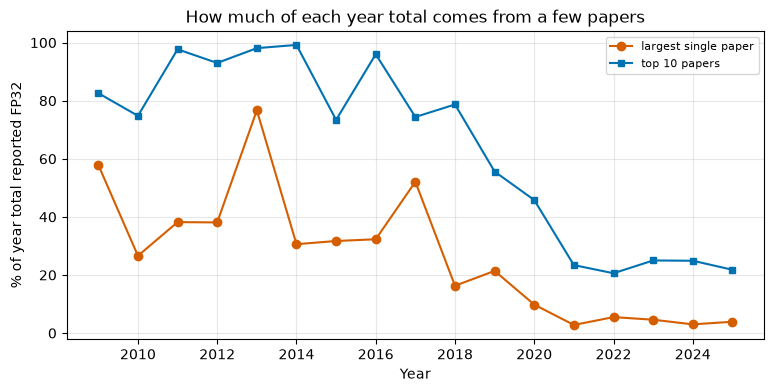

shape: (17, 5)
┌──────┬───────┬────────────┬─────────────┬──────────────┐
│ year ┆ n     ┆ top1_share ┆ top10_share ┆ total_pflops │
│ ---  ┆ ---   ┆ ---        ┆ ---         ┆ ---          │
│ i64  ┆ i64   ┆ f64        ┆ f64         ┆ f64          │
╞══════╪═══════╪════════════╪═════════════╪══════════════╡
│ 2009 ┆ 49    ┆ 0.579      ┆ 0.826       ┆ 0.2          │
│ 2010 ┆ 134   ┆ 0.266      ┆ 0.748       ┆ 0.5          │
│ 2011 ┆ 187   ┆ 0.382      ┆ 0.977       ┆ 11.4         │
│ 2012 ┆ 254   ┆ 0.381      ┆ 0.93        ┆ 6.6          │
│ 2013 ┆ 314   ┆ 0.767      ┆ 0.981       ┆ 36.8         │
│ 2014 ┆ 399   ┆ 0.306      ┆ 0.992       ┆ 240.7        │
│ 2015 ┆ 555   ┆ 0.317      ┆ 0.734       ┆ 10.4         │
│ 2016 ┆ 929   ┆ 0.323      ┆ 0.96        ┆ 199.7        │
│ 2017 ┆ 1979  ┆ 0.521      ┆ 0.744       ┆ 100.5        │
│ 2018 ┆ 4313  ┆ 0.163      ┆ 0.787       ┆ 512.9        │
│ 2019 ┆ 4917  ┆ 0.214      ┆ 0.556       ┆ 267.9        │
│ 2020 ┆ 12700 ┆ 0.098      ┆ 0.458      

In [10]:
# top-k contribution diagnostic — publish with any total/Gini claim
rows = []
for y in sorted(cap.filter(pl.col('year').is_not_null())['year'].unique().to_list()):
    v = (cap.filter((pl.col('year') == y) & ~pl.col('spec_missing_fp32'))
         ['reported_fp32_gflops'].drop_nulls().sort(descending=True))
    if len(v) < MIN_PAPERS_PER_YEAR:
        continue
    tot = v.sum()
    rows.append({'year': y, 'n': len(v),
                 'top1_share': round(v[0] / tot, 3),
                 'top10_share': round(v[:10].sum() / tot, 3),
                 'total_pflops': round(tot / 1e6, 1)})
topk = pl.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(topk['year'], 100 * topk['top1_share'], marker='o', color=C_FRONT,
        label='largest single paper')
ax.plot(topk['year'], 100 * topk['top10_share'], marker='s', ms=4, color=C_MED,
        label='top 10 papers')
ax.set(xlabel='Year', ylabel='% of year total reported FP32',
       title='How much of each year total comes from a few papers')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()
with pl.Config(tbl_rows=20):
    print(topk)

## 5.5b Inequality of reported compute across works

Inequality is tracked three ways, because each answers a different question:

1. **Lorenz curves** (benchmark years) — the shape of the distribution: what
   share of all reported compute the least-resourced papers account for.
2. **Gini with bootstrap CIs** — level and trend, with uncertainty. The CIs are
   what keep the noisy pre-2016 years (few hundred papers, one large-cluster
   paper) from being over-read as a trend.
3. **Theil index, decomposed between-field vs within-field** — is the compute
   divide about *which field you work in*, or about *who you are within a
   field*? Theil is additively decomposable, which Gini is not; a
   within-dominant decomposition implies field-targeted compute policy would
   miss most of the inequality.

*Inequality here is in reported nameplate capacity, so it reflects both real
resource differences and differences in what authors choose to report.*

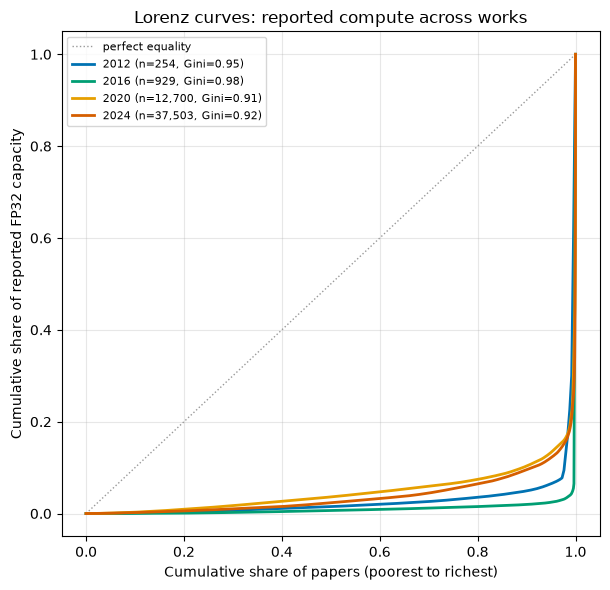

In [11]:
def lorenz(v: np.ndarray):
    v = np.sort(v[np.isfinite(v) & (v > 0)])
    cum = np.cumsum(v) / v.sum()
    return np.insert(np.arange(1, v.size + 1) / v.size, 0, 0), np.insert(cum, 0, 0)

BENCH = [y for y in (2012, 2016, 2020, 2024)
         if cap.filter((pl.col('year') == y) & ~pl.col('spec_missing_fp32')).height >= 100]
fig, ax = plt.subplots(figsize=(6.2, 6))
ax.plot([0, 1], [0, 1], color='#999999', lw=1, ls=':', label='perfect equality')
for y, c in zip(BENCH, ['#0072B2', '#009E73', '#E69F00', '#D55E00']):
    v = (cap.filter((pl.col('year') == y) & ~pl.col('spec_missing_fp32'))
         ['reported_fp32_gflops'].drop_nulls().to_numpy().astype(float))
    x, cum = lorenz(v)
    ax.plot(x, cum, color=c, lw=2, label=f'{y} (n={v.size:,}, Gini={gini(v):.2f})')
ax.set(xlabel='Cumulative share of papers (poorest to richest)',
       ylabel='Cumulative share of reported FP32 capacity',
       title='Lorenz curves: reported compute across works')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

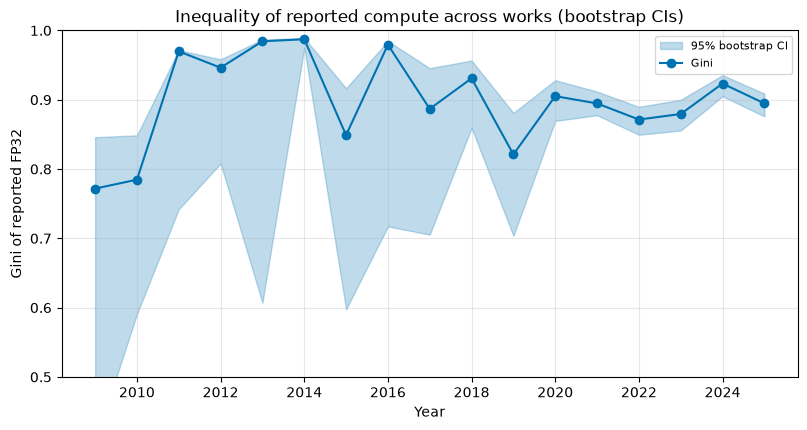

shape: (17, 5)
┌──────┬───────┬───────┬───────┬───────┐
│ year ┆ n     ┆ gini  ┆ lo    ┆ hi    │
│ ---  ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ i64  ┆ i64   ┆ f64   ┆ f64   ┆ f64   │
╞══════╪═══════╪═══════╪═══════╪═══════╡
│ 2009 ┆ 49    ┆ 0.772 ┆ 0.406 ┆ 0.846 │
│ 2010 ┆ 134   ┆ 0.785 ┆ 0.591 ┆ 0.849 │
│ 2011 ┆ 187   ┆ 0.97  ┆ 0.742 ┆ 0.972 │
│ 2012 ┆ 254   ┆ 0.946 ┆ 0.808 ┆ 0.958 │
│ 2013 ┆ 314   ┆ 0.984 ┆ 0.607 ┆ 0.987 │
│ 2014 ┆ 399   ┆ 0.987 ┆ 0.975 ┆ 0.989 │
│ 2015 ┆ 555   ┆ 0.849 ┆ 0.597 ┆ 0.917 │
│ 2016 ┆ 929   ┆ 0.979 ┆ 0.717 ┆ 0.985 │
│ 2017 ┆ 1979  ┆ 0.887 ┆ 0.705 ┆ 0.946 │
│ 2018 ┆ 4313  ┆ 0.931 ┆ 0.859 ┆ 0.957 │
│ 2019 ┆ 4917  ┆ 0.821 ┆ 0.704 ┆ 0.881 │
│ 2020 ┆ 12700 ┆ 0.905 ┆ 0.869 ┆ 0.928 │
│ 2021 ┆ 19931 ┆ 0.895 ┆ 0.878 ┆ 0.912 │
│ 2022 ┆ 23528 ┆ 0.871 ┆ 0.85  ┆ 0.89  │
│ 2023 ┆ 30952 ┆ 0.879 ┆ 0.856 ┆ 0.9   │
│ 2024 ┆ 37503 ┆ 0.923 ┆ 0.905 ┆ 0.935 │
│ 2025 ┆ 32255 ┆ 0.895 ┆ 0.876 ┆ 0.909 │
└──────┴───────┴───────┴───────┴───────┘


In [12]:
rng = np.random.default_rng(42)
B = 300
rows = []
for y in sorted(cap.filter(pl.col('year').is_not_null())['year'].unique().to_list()):
    v = (cap.filter((pl.col('year') == y) & ~pl.col('spec_missing_fp32'))
         ['reported_fp32_gflops'].drop_nulls().to_numpy().astype(float))
    if v.size < MIN_PAPERS_PER_YEAR:
        continue
    boots = [gini(rng.choice(v, v.size, replace=True)) for _ in range(B)]
    rows.append({'year': y, 'n': v.size, 'gini': gini(v),
                 'lo': float(np.nanpercentile(boots, 2.5)),
                 'hi': float(np.nanpercentile(boots, 97.5))})
gc = pl.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.fill_between(gc['year'], gc['lo'], gc['hi'], color=C_MED, alpha=0.25,
                label='95% bootstrap CI')
ax.plot(gc['year'], gc['gini'], marker='o', color=C_MED, label='Gini')
ax.set(xlabel='Year', ylabel='Gini of reported FP32', ylim=(0.5, 1.0),
       title='Inequality of reported compute across works (bootstrap CIs)')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()
with pl.Config(tbl_rows=20):
    print(gc.with_columns(pl.col('gini').round(3), pl.col('lo').round(3), pl.col('hi').round(3)))

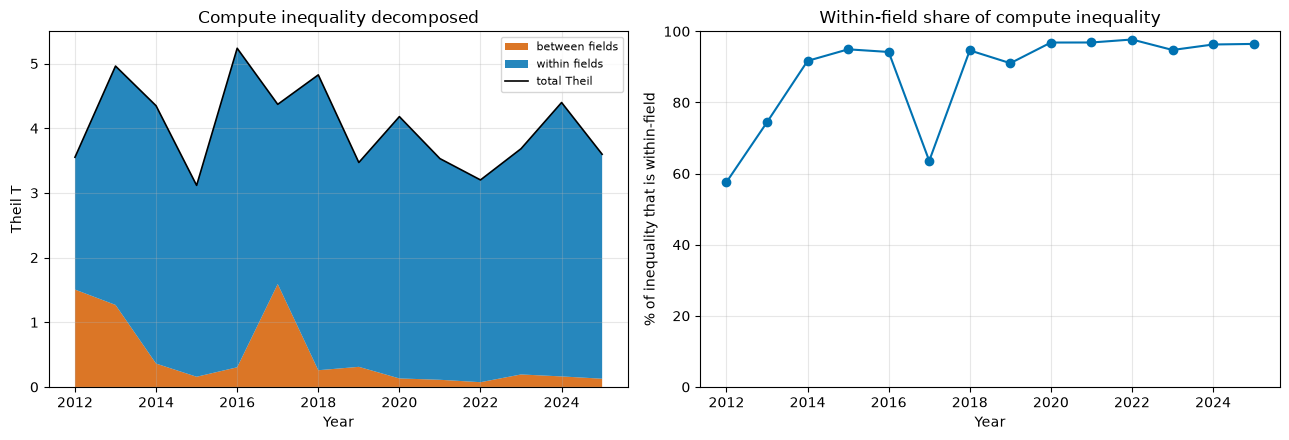

shape: (14, 6)
┌──────┬───────┬─────────────┬───────────────┬──────────────┬──────────────┐
│ year ┆ n     ┆ theil_total ┆ between_field ┆ within_field ┆ within_share │
│ ---  ┆ ---   ┆ ---         ┆ ---           ┆ ---          ┆ ---          │
│ i64  ┆ i64   ┆ f64         ┆ f64           ┆ f64          ┆ f64          │
╞══════╪═══════╪═════════════╪═══════════════╪══════════════╪══════════════╡
│ 2012 ┆ 253   ┆ 3.551       ┆ 1.506         ┆ 2.046        ┆ 0.576        │
│ 2013 ┆ 313   ┆ 4.961       ┆ 1.268         ┆ 3.693        ┆ 0.744        │
│ 2014 ┆ 399   ┆ 4.348       ┆ 0.361         ┆ 3.986        ┆ 0.917        │
│ 2015 ┆ 554   ┆ 3.117       ┆ 0.158         ┆ 2.959        ┆ 0.949        │
│ 2016 ┆ 921   ┆ 5.237       ┆ 0.304         ┆ 4.933        ┆ 0.942        │
│ 2017 ┆ 1966  ┆ 4.369       ┆ 1.591         ┆ 2.778        ┆ 0.636        │
│ 2018 ┆ 4296  ┆ 4.825       ┆ 0.258         ┆ 4.567        ┆ 0.946        │
│ 2019 ┆ 4895  ┆ 3.47        ┆ 0.311         ┆ 3.159        ┆

In [13]:
def theil(v: np.ndarray) -> float:
    """Theil T index; additively decomposable into between/within groups."""
    v = v[np.isfinite(v) & (v > 0)]
    if v.size == 0:
        return float('nan')
    mu = v.mean()
    return float(np.mean((v / mu) * np.log(v / mu)))

rows = []
for y in sorted(cap.filter(pl.col('year').is_not_null())['year'].unique().to_list()):
    sub = cap.filter((pl.col('year') == y) & ~pl.col('spec_missing_fp32')
                     & pl.col('field').is_not_null()
                     & (pl.col('reported_fp32_gflops') > 0))
    v = sub['reported_fp32_gflops'].to_numpy().astype(float)
    if v.size < 200:
        continue
    total, mu = theil(v), v.mean()
    between = within = 0.0
    for (f,), g in sub.group_by('field'):
        gv = g['reported_fp32_gflops'].to_numpy().astype(float)
        s = gv.sum() / v.sum()                     # group share of compute
        if gv.size == 0 or gv.mean() <= 0:
            continue
        between += s * np.log(gv.mean() / mu)
        within += s * theil(gv)
    rows.append({'year': y, 'n': v.size, 'theil_total': total,
                 'between_field': between, 'within_field': within,
                 'within_share': within / total if total else float('nan')})
th = pl.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].stackplot(th['year'], th['between_field'], th['within_field'],
                  labels=['between fields', 'within fields'],
                  colors=['#D55E00', '#0072B2'], alpha=0.85)
axes[0].plot(th['year'], th['theil_total'], color='black', lw=1.2, label='total Theil')
axes[0].set(xlabel='Year', ylabel='Theil T', title='Compute inequality decomposed')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].plot(th['year'], 100 * th['within_share'], marker='o', color=C_MED)
axes[1].set(xlabel='Year', ylabel='% of inequality that is within-field', ylim=(0, 100),
            title='Within-field share of compute inequality')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=20):
    print(th.with_columns(pl.col('theil_total').round(3), pl.col('between_field').round(3),
                          pl.col('within_field').round(3), pl.col('within_share').round(3)))

## 5.6 Field differences in reported capacity

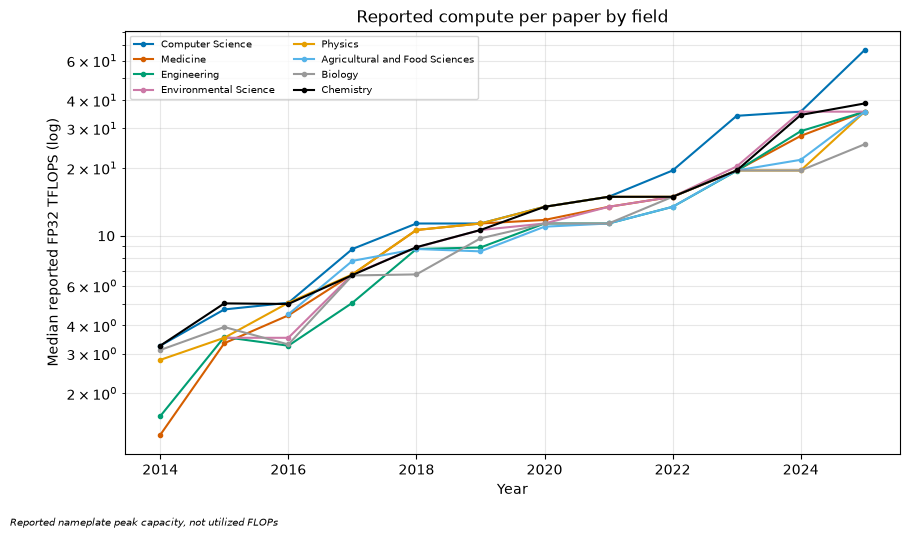

In [14]:
top_fields = (cap.filter(pl.col('field').is_not_null())
              .group_by('field').agg(n=pl.len()).sort('n', descending=True)
              .head(8)['field'].to_list())
fd = (cap.filter(~pl.col('spec_missing_fp32') & pl.col('field').is_in(top_fields)
                 & pl.col('year').is_between(2014, YEAR_MAX))
      .group_by('field', 'year').agg(n=pl.len(), med=pl.col('reported_fp32_gflops').median())
      .filter(pl.col('n') >= 10).sort('year'))
fig, ax = plt.subplots(figsize=(10, 5.5))
PAL = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9', '#999999', '#000000']
for i, f in enumerate(top_fields):
    s = fd.filter(pl.col('field') == f)
    if s.height > 2:
        ax.plot(s['year'], s['med'] / 1000, marker='o', ms=3, label=f, color=PAL[i % len(PAL)])
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
ax.set(xlabel='Year', ylabel='Median reported FP32 TFLOPS (log)',
       title='Reported compute per paper by field')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3, which='both')
fig.text(0.01, -0.02, CAVEAT, fontsize=7, style='italic'); plt.show()